In [24]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from scipy import stats

escape

In [25]:
# load data
WT_escape_angle = pd.read_csv('extract_escape_WT_labeled+motion_mode_data.csv')

In [26]:
# prepare copy for last_switch analysis
WT_escape_angle_last_switch = WT_escape_angle.copy()
# remove row if last_switch is empty or '/'
print("before removal: ", WT_escape_angle_last_switch.shape)
WT_escape_angle_last_switch = WT_escape_angle_last_switch[WT_escape_angle_last_switch['last_switch'].notnull()]
WT_escape_angle_last_switch = WT_escape_angle_last_switch[WT_escape_angle_last_switch['last_switch'] != '/']
# change last_switch to int
WT_escape_angle_last_switch['last_switch'] = WT_escape_angle_last_switch['last_switch'].astype(int)
print("after removal: ", WT_escape_angle_last_switch.shape)

# prepare copy for time_on_hole analysis
WT_escape_angle_time_on_hole = WT_escape_angle.copy()
# remove row if on_hole_start is empty or '/' or on_hole_end is empty or '/'
print("before removal: ", WT_escape_angle_time_on_hole.shape)
WT_escape_angle_time_on_hole = WT_escape_angle_time_on_hole[WT_escape_angle_time_on_hole['on_hole_start'].notnull()]
WT_escape_angle_time_on_hole = WT_escape_angle_time_on_hole[WT_escape_angle_time_on_hole['on_hole_start'] != '/']
WT_escape_angle_time_on_hole = WT_escape_angle_time_on_hole[WT_escape_angle_time_on_hole['on_hole_end'].notnull()]
WT_escape_angle_time_on_hole = WT_escape_angle_time_on_hole[WT_escape_angle_time_on_hole['on_hole_end'] != '/']
# change on_hole_start and on_hole_end to int
WT_escape_angle_time_on_hole['on_hole_start'] = WT_escape_angle_time_on_hole['on_hole_start'].astype(int)
WT_escape_angle_time_on_hole['on_hole_end'] = WT_escape_angle_time_on_hole['on_hole_end'].astype(int)
print("after removal: ", WT_escape_angle_time_on_hole.shape)

# prepare copy for angle analysis, based on time_on_hole dataset
WT_escape_angle_analysis = WT_escape_angle_time_on_hole.copy()
# remove row if 'outside_frame' is '/'; or if notes contains 2_holes or abnormal
print("before removal: ", WT_escape_angle_analysis.shape)
WT_escape_angle_analysis = WT_escape_angle_analysis[WT_escape_angle_analysis['outside_frame'] != '/']
WT_escape_angle_analysis = WT_escape_angle_analysis[~WT_escape_angle_analysis['notes'].fillna('').str.contains('2_holes|abnormal')]
print("after removal: ", WT_escape_angle_analysis.shape)

before removal:  (147, 33)
after removal:  (127, 33)
before removal:  (147, 33)
after removal:  (131, 33)
before removal:  (131, 33)
after removal:  (98, 33)


In [27]:
# last 
# change on_hole_end to int, set as 0 if empty or '/'
WT_escape_angle_last_switch['on_hole_end'] = pd.to_numeric(WT_escape_angle_last_switch['on_hole_end'], errors='coerce').fillna(0).astype(int)
WT_escape_angle_last_switch['on_hole_start'] = pd.to_numeric(WT_escape_angle_last_switch['on_hole_start'], errors='coerce').fillna(0).astype(int)
WT_escape_angle_last_switch['time_since_last_switch'] = (
    WT_escape_angle_last_switch[['frame', 'on_hole_end']].max(axis=1) 
    - WT_escape_angle_last_switch['last_switch'] + 1
) * WT_escape_angle_last_switch['exposure_time'] / 1000
# filter out if time > 12s
WT_escape_angle_last_switch = WT_escape_angle_last_switch[WT_escape_angle_last_switch['time_since_last_switch'] < 12]

In [28]:
# print mean and std of time since last switch, forward I
print('forward I: ', WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_c']['time_since_last_switch'].mean().round(1), WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_c']['time_since_last_switch'].std().round(1))
print('forward II: ', WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_s']['time_since_last_switch'].mean().round(1), WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_s']['time_since_last_switch'].std().round(1))
print('backward: ', WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'b']['time_since_last_switch'].mean().round(1), WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'b']['time_since_last_switch'].std().round(1))

forward I:  2.8 2.6
forward II:  2.1 1.8
backward:  0.9 0.8


Compare with motion mode duration

In [29]:
# data
motion_duration_path = r".\residence_time_F20_WT.csv"
motion_duration = pd.read_csv(motion_duration_path)

# convert residence_time from frame to second, interval = 21ms
motion_duration['residence_time_s'] = motion_duration['residence_time'] * 21 / 1000

In [30]:
# separate based on inner_diameter/body_length, threshold 3.75
threshold = 3.75
motion_duration['capsule_type'] = pd.cut(motion_duration['inner_diameter']/motion_duration['body_length'], bins=[0, threshold, 10], labels=['small', 'large'])
# print num of each type
print(motion_duration['capsule_type'].value_counts())

capsule_type
large    523
small    465
Name: count, dtype: int64


In [31]:
# notes for removing
# Away_from_surface somersault: Backward
# Circling: Forward I
# Shaking: impeded Backward
# Near_surface spinning: Forward II
# Skating: Forward II
# Linear: short motion modes, remove
# Stuck_on_hole: remove
# Stop: impeded Backward

# relabel motion_mode
motion_duration['motion_mode_relabel'] = motion_duration['motion_mode']
motion_duration['motion_mode_relabel'] = motion_duration['motion_mode_relabel'].replace({'Away_from_surface somersault': 'Backward', 'Circling': 'Forward I', 'Shaking': 'impeded Backward', 'Near_surface spinning': 'Forward II', 'Skating': 'Forward II', 'Linear': 'remove', 'Stuck_on_hole': 'remove', 'Stop': 'impeded Backward'})


In [32]:
# print how many motion modes each type has
motion_duration_large = motion_duration[motion_duration['capsule_type'] == 'large']
motion_duration_small = motion_duration[motion_duration['capsule_type'] == 'small']
print('large: ', motion_duration_large['motion_mode_relabel'].value_counts())
print('')
print('small: ', motion_duration_small['motion_mode_relabel'].value_counts())

large:  motion_mode_relabel
Backward            268
Forward I           140
Forward II           98
remove               10
impeded Backward      7
Name: count, dtype: int64

small:  motion_mode_relabel
impeded Backward    186
Forward II          152
Forward I            69
remove               31
Backward             27
Name: count, dtype: int64


In [33]:
# mean and std of each motion mode
motion_duration_large_mean = motion_duration_large.groupby('motion_mode_relabel')['residence_time_s'].mean()
motion_duration_large_std = motion_duration_large.groupby('motion_mode_relabel')['residence_time_s'].std()
motion_duration_small_mean = motion_duration_small.groupby('motion_mode_relabel')['residence_time_s'].mean()
motion_duration_small_std = motion_duration_small.groupby('motion_mode_relabel')['residence_time_s'].std()
print('large: ')
print(motion_duration_large_mean)
print('')
print('small: ')
print(motion_duration_small_mean)

large: 
motion_mode_relabel
Backward            1.570299
Forward I           2.240100
Forward II          2.655643
impeded Backward    1.806000
remove              1.104600
Name: residence_time_s, dtype: float64

small: 
motion_mode_relabel
Backward            1.508111
Forward I           2.775348
Forward II          2.311105
impeded Backward    1.520468
remove              0.646258
Name: residence_time_s, dtype: float64


len of each group:
Forward I: 28
Forward I large: 140
Forward II: 24
Forward II large: 98
Backward: 74
Backward large: 268
Escape Time vs. Motion Duration
Pairwise comparisons:
FI: 4.398e-01
FII: 4.320e-01
B: 3.208e-11
U n.s.
U n.s.
U ***


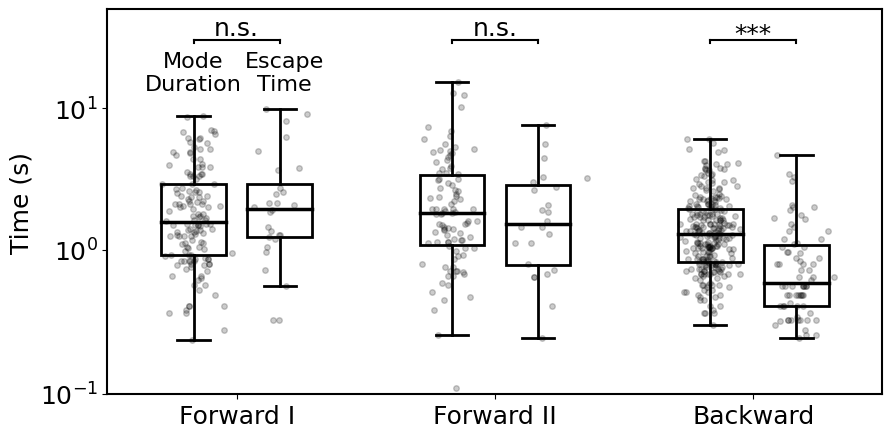

In [ ]:
# Define line thickness
thickness_axis = 1.5
thickness_box = 1.5
thickness_mean = 1.5
thickness_test = 1.5

key_parameter = 'Escape Time vs. Motion Duration'

# Define box plot colors (minimal palette)
# colors = ['#333333', 'dimgray', 'darkgray']
# colors = ['#333333', 'dimgray', 'darkgray', 'lightgray', 'silver', 'gainsboro']
# Create a figure to plot all key parameters
# plt.figure(figsize=(6, 5.5))
plt.figure(figsize=(10, 5))

# Get the data for each dataset
data_1 = WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_c']['time_since_last_switch'].dropna()
data_2 = WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_s']['time_since_last_switch'].dropna()
data_3 = WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'b']['time_since_last_switch'].dropna()

data_4 = motion_duration_large[motion_duration_large['motion_mode_relabel'] == 'Forward I']['residence_time_s'].dropna()
data_5 = motion_duration_large[motion_duration_large['motion_mode_relabel'] == 'Forward II']['residence_time_s'].dropna()
data_6 = motion_duration_large[motion_duration_large['motion_mode_relabel'] == 'Backward']['residence_time_s'].dropna()

# Ensure data are numeric arrays
data_1 = np.array(data_1, dtype=np.float64)
data_2 = np.array(data_2, dtype=np.float64)
data_3 = np.array(data_3, dtype=np.float64)
data_4 = np.array(data_4, dtype=np.float64)
data_5 = np.array(data_5, dtype=np.float64)
data_6 = np.array(data_6, dtype=np.float64)

# convert to log
data_1 = np.log10(data_1 + 0.000001)  # Add a small constant to avoid log(0)
data_2 = np.log10(data_2 + 0.000001)  # Add a small constant to avoid log(0)
data_3 = np.log10(data_3 + 0.000001)  # Add a small constant to avoid log(0)
data_4 = np.log10(data_4 + 0.000001)  # Add a small constant to avoid log(0)
data_5 = np.log10(data_5 + 0.000001)  # Add a small constant to avoid log(0)
data_6 = np.log10(data_6 + 0.000001)  # Add a small constant to avoid log(0)

# # sort data
# data_1 = np.sort(data_1)
# data_2 = np.sort(data_2)
# data_3 = np.sort(data_3)
# len_FI = len(data_1)
# len_FII = len(data_2)
# len_B = len(data_3)
# # # remove outliers: > k*std, < k*std
# # outlier_k = 3
# # data_1 = data_1[(data_1 > np.mean(data_1) - outlier_k * np.std(data_1)) & (data_1 < np.mean(data_1) + outlier_k * np.std(data_1))]
# # data_2 = data_2[(data_2 > np.mean(data_2) - outlier_k * np.std(data_2)) & (data_2 < np.mean(data_2) + outlier_k * np.std(data_2))]
# # data_3 = data_3[(data_3 > np.mean(data_3) - outlier_k * np.std(data_3)) & (data_3 < np.mean(data_3) + outlier_k * np.std(data_3))]

# print('before - after removing outliers:')
# print(f'FI: {len_FI} - {len(data_1)}')
# print(f'FII: {len_FII} - {len(data_2)}')
# print(f'B: {len_B} - {len(data_3)}')
# Perform normality test
normality = all([len(data) > 2 and stats.shapiro(data)[1] > 0.05 for data in [data_1, data_2, data_3, data_4, data_5, data_6]])

def pairwise_test(data1, data2):
    if normality:
        stat, p_value = stats.ttest_ind(data1, data2, equal_var=False)  # Welch's t-test
        stat_symbol = "t"
    else:
        stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')  # Mann-Whitney U test
        stat_symbol = "U"
    return stat, p_value, stat_symbol

# Compute pairwise statistics and p-values
compare_FI, p_FI, symbol_FI = pairwise_test(data_1, data_4)
compare_FII, p_FII, symbol_FII = pairwise_test(data_2, data_5)
compare_B, p_B, symbol_B = pairwise_test(data_3, data_6)

# Function to assign significance labels
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

# Generate significance labels
sig_FI = significance_label(p_FI)
sig_FII = significance_label(p_FII)
sig_B = significance_label(p_B)

# # Create box plot
# bp = plt.boxplot([data_1, data_4, data_2, data_5, data_3, data_6], vert=True, patch_artist=True, widths=0.5,
#                     medianprops={'color': 'black', 'linewidth': thickness_mean},
#                     boxprops=dict(linewidth=thickness_box), whiskerprops=dict(linewidth=thickness_axis),
#                     capprops=dict(linewidth=thickness_axis))
# # Set box colors
# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)

# Palette
palette = {
    'Forward I': 'white',
    'Forward I large': 'white',
    'Forward II': 'white',
    'Forward II large': 'white',
    'Backward': 'white',
    'Backward large': 'white'
}

# Prepare DataFrame
df = pd.DataFrame({
    'value': np.concatenate([data_1, data_4, data_2, data_5, data_3, data_6]),
    'group': ['Forward I'] * len(data_1) + ['Forward I large'] * len(data_4) + ['Forward II'] * len(data_2) + ['Forward II large'] * len(data_5) + ['Backward'] * len(data_3) + ['Backward large'] * len(data_6)
})

# print len of each group
print('len of each group:')
print(f'Forward I: {len(data_1)}')
print(f'Forward I large: {len(data_4)}')
print(f'Forward II: {len(data_2)}')
print(f'Forward II large: {len(data_5)}')
print(f'Backward: {len(data_3)}')
print(f'Backward large: {len(data_6)}')

# group_order = ['Forward I', 'Forward I large', 'Forward II', 'Forward II large', 'Backward', 'Backward large']
group_order = ['Forward I large', 'Forward I', 'Forward II large', 'Forward II', 'Backward large', 'Backward']

# Group the data for boxplot
data_ordered = [df[df['group'] == group]['value'].values for group in group_order]

positions = [0, 0.4, 1.2, 1.6, 2.4, 2.8]
ax = plt.gca()
# bp = ax.boxplot(
#     data_ordered,
#     positions=range(len(group_order)),
#     widths=0.3,
#     patch_artist=True,
#     boxprops=dict(facecolor='none', edgecolor='k', linewidth=2, alpha=1),
#     whiskerprops=dict(color='k', linewidth=2, alpha = 1),
#     capprops=dict(color='k', linewidth=2, alpha = 1),
#     medianprops=dict(color='k', linewidth=2.5, alpha=1),
#     flierprops=dict(marker='o', markersize=0)
# )
bp = ax.boxplot(
    data_ordered,
    positions=positions,
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor='k', linewidth=2, alpha=1),
    whiskerprops=dict(color='k', linewidth=2, alpha = 1),
    capprops=dict(color='k', linewidth=2, alpha = 1),
    medianprops=dict(color='k', linewidth=2.5, alpha=1),
    flierprops=dict(marker='o', markersize=0)
)

# Strip plot
# fix random seed for reproducibility
np.random.seed(2)
# sns.stripplot(data=df, x='group', y='value', order=group_order,
#               color='black', size=4, jitter=0.15, alpha=0.2)

# use scatter plot to plot shifted strip plot
group_to_x = dict(zip(group_order, positions))
df['x_pos'] = df['group'].map(group_to_x)
ax.scatter(df['x_pos'] + np.random.normal(0, 0.055, size=len(df)),  # jitter by hand
           df['value'],
           color='black', s=16, alpha=0.2)

# # ---alternative color---
# color_gray_light = '#C4C4C4'
# color_gray_dark = '#7A7A7A'
# colors = [color_gray_light, color_gray_dark] 
# group_idx = {group: i for i, group in enumerate(group_order)}
# group_to_x = dict(zip(group_order, positions))
# df['x_pos'] = df['group'].map(group_to_x)
# df['group_idx'] = df['group'].map(group_idx)
# for group in group_order:
#     sub_df = df[df['group'] == group]
#     i = group_idx[group]
#     color = colors[i % 2]
#     ax.scatter(
#         sub_df['x_pos'] + np.random.normal(0, 0.055, size=len(sub_df)),
#         sub_df['value'],
#         color=color,
#         s=16,
#         alpha=0.2
#     )


# Add significance annotations
y_max = np.nanmax([np.nanmax(data_1), np.nanmax(data_2), np.nanmax(data_3), np.nanmax(data_4), np.nanmax(data_5), np.nanmax(data_6)])
y_line = y_max * 1.25
vline_height = y_max * 0.02

# FI
plt.plot([0, 0.4], [y_line, y_line], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([0.4, 0.4], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (right)
# FII
plt.plot([1.2, 1.6], [y_line , y_line ], color='black', linewidth=thickness_axis)  # Short line
plt.plot([1.2, 1.2], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([1.6, 1.6], [y_line, y_line  - vline_height], color='black')  # Adjusted vertical line (right)

# B
plt.plot([2.4, 2.8], [y_line , y_line ], color='black', linewidth=thickness_axis)  # Short line
plt.plot([2.4, 2.4], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2.8, 2.8], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (right)

# Add significance labels
# -y_max*0.005 if "n.s."
# -y_max*0.01 if "*" or "**" or "***"
plt.text(0.2, y_line * 1 - y_max*0.005, sig_FI, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1.4, y_line * 1 - y_max*0.005, sig_FII, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(2.6, y_line * 1 - y_max*0.04, sig_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black

# Set labels
# plt.title(f'{key_parameter}')
print(f'{key_parameter}')
# plt.xticks([0, 1, 2, 3, 4, 5], [f'Forward I', f'Forward I\nLarge', f'Forward II', f'Forward II\nLarge', f'Backward', f'Backward\nLarge'])
# plt.ylabel(f'{key_parameter}')
plt.ylabel('Time (s)')
# ylim
plt.ylim(-1, 1.7)
plt.xlim(-0.4, 3.2)

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(18)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=6)
# set x ticks
ax.set_xticks([0.2, 1.4, 2.6])
# set x tick labels
ax.set_xticklabels([f'Forward I', f'Forward II', f'Backward'])
# set y ticks
ax.set_yticks([-1.02, 0, 1])
# set y tick labels
ax.set_yticklabels([r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$'])

# add text "Mode Duration"
plt.text(0.0, 1.25, 'Mode\nDuration', ha='center', va='center', fontsize=16, color='black')
# add text "Escape Time"
plt.text(0.42, 1.25, 'Escape\nTime', ha='center', va='center', fontsize=16, color='black')


# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('{}-boxplot.png'.format(key_parameter), format='png', dpi=900, transparent=True, bbox_inches='tight')

# print pFI, pFII, pB
print(f'Pairwise comparisons:')
print(f'FI: {p_FI:.3e}')
print(f'FII: {p_FII:.3e}')
print(f'B: {p_B:.3e}')